# Final Project for Chem 277A #

### Research Question ###
Can we (a) identify natural products that share key binding-relevant substructures of rapamycin and (b) evaluate whether they exhibit strong binding affinity to FKBP12, a protein that forms a complex with rapamycin to inhibit mTORC1, a key driver of aging?


### Methods ###
This project integrates chemical structure features with functional binding affinity to identify structure-function relationships. The FKBP-12-rapamycin complex was obtained from the Protein Data Bank and processed with RDKit to extract the rapamycin binding fragment and characterize the FKBP12 binding pocket.  Candidate molecules were sourced from the COCONUT natural products database (~740K compounds) and filtered based on structural features. Morgan fingerprints were used to characterize the rapamycin binding fragment and candidate molecules, with similarity between them measured using Tanimoto and Tversky metrics.  Principal component analysis (PCA) and K-Means clustering were applied to the chemical feature space of the candidate molecules. AutoDock Vina was used to estimate binding affinity of candidate molecules with the FKBP12 binding pocket.

### Analysis Choices ###
Analysis choices were broken down in terms of the major components involved in this project, which are summarized below. 

#### Data Processing / Harmonization:
##### PDB database FKBP12-Rapamycin complex sourced (CIF file)
Data processing and harmonization for the FKBP12-Rapamycing complex included using the CIF file from the PDB database, identifying the rapamycin atoms, inspecting their structure, and extracting the associated atoms. The identified atoms from this rapamycin binding region were then converted to an RDKit molecular object, with pharmacophore associated atoms mapped to RDKit indices. Finally this extracted rapamycin binding fragment was satizied with RDKit to ensure molecular integrity was maintained. 

##### Coconut database of natural products sourced (CSV file)
Data processing and harmonization for the candidate molecules from the Coconut database was performed on the full database CSV file, where each molecule's SMILES data was converted to a corresponding dataset of RDKit molecule objects. Additional features and COCONUT dataset parametes were added to the RDKit dataset.  This was then prefiltered to remove data with missing key features such as mw, hba/hbd, TPSA, logP, rings, aromatic rings, and amides. It was further prefiltered to exclude aotms with parameters which are not associated with valid drug targets such as being too small or large. Invalid and duplicate SMILES entries were also removed. This resulted in ~97K candidate molecules. 

##### Morgan Fingerprints and Similarity Scoring:
Morgan fingerprints were calculated for rapamycin binding fragment and the candidate molecules, using a bit length of 2048, and testing radius 1 and radius 2 since each has associated tradeoffs, which could be evaluated during subsequent processing steps. Similarity scoring was performed between the rapamycin binding region template and all candidate molecules, using both Tanimoto and Tversky methods. Tversky was included because it has two hyperparameters which control whether similarity scoring penalizes extra structural features present, or penalizing absence of desired structural features. We tested two settings of these hyperparameters. The first was referred to as 'symmetric', meaning we penalized both attributes equally. The second was referred to a 'feature-focused' which only penalized absence of desired features and minimized the penalty for superfluous features. This was done since candidate molecules had a broad diversity of size, and only the binding region attributes were desired, so superfluous attributes were deemed acceptable. Tversky consistently scored higher similarity scores than Tanimoto, but since we only sought a similarity metric which stratified results by similarity, the scale difference was not important. We measure the extent they both stratified candidate molecules similarly by calculating the correlation between Tanimoto and Tversky methods for both the entire dataset and for those with the best binding affinity.  

##### Feature Clustering
Feature clustering connected the similarity scoring to the features present in each candidate molecule (mw, hba/hbd, Rings, Aromatic rings, TPSA, logP). PCA was used for displaying results, with K-Means clustering used to identify patterns among the features being associated with binding affinity. A silhouette plot was produced to help identify the optimal number of clusters (k=2 clusters), but a secondary number (k=4 clusters) was also examined to determine if subclusters may exist. 

##### Docking
Docking measurements were made by first extract the FKBP12 binding site atoms and convert them to an RDKit object. We validated the docking box by size, but alternative sizes could and should also be considered in future work. 1000 top binding candidate ligands were prepared to address anomolies from real chemistry associated with x-ray crystallography determination of candidate molecule structures. This included removing water and adding hydrogen atoms. 971 of them survived this process, which were then coverted back to SMILES, then to PDB and PDBQT files using Babel. AutoDoc Vina was used to measure candidate molecules binding affinity with the FKBP12 binding pocket. Certain hyperparameters with Vina had to be adjusted (exhaustiveness=4, n_poses=5) in order to process all 971 molecules within a reasonable time with a laptop computer. Additional hyperparameter choices should be explored in future work. 

##### Relate Binding Affinity to Model
The relationship between similarity scoring and binding affinity was analyzed by plotting Vina scores against different number of candidate molecules ranked by similarity scoring. The relationhip between features and binding was also incorporated on this plot by separating the two primary clusters from K-Means along the PC1 dimension on the graph, indicating which how each of the two primary clusters each tracked with binding affinity and similarity scoring. A box plot further looked at key features split between the two primary clusters, one cluster having higher bonding affinity than the other. 

### Results ### 





### Conclusions and Future Work ###

### Study Limitations and Future Work ###



### References ###

## Detailed Workflow ##

Phase 0: Exploratory Data Analysis
A. Load COCONUT Database (Full version)
B. Sanity check: Verify RDKit successfully turns a SMILES string into a molecule object
C. Quantify extent SMILES data is missing
D. Calculate molecular weight and show distribution from SMILES using RDKit


Phase 1: Characterize Rapamycin Binding Fragment and Candidate Molecules, Morgan Fingerprints and Similary Scoring
A. Load FKBP12-rapamycin structure (CIF file)
  1. Use the RCSB Protein Data Bank, https://www.rcsb.org/
  2. Search FKBP12 rapamycin 1FKB structure (https://www.rcsb.org/structure/1FKB)
  3. (NO LONGER TRUE) Download the 1FKB.cif file
  3. Download the 'Biological Assembly 1 (PDB - gz)' file
  4. Unzip file
  5. Verify loaded in to RDKit
B. Inspect structure
C. Identify contact atoms
  1. The Protein chain (A), Rapamycin ligand (RAP), Residue ID (108)
  2. Identify rapaymcin atoms contacting FKBP12 (defined binding region)
     - Rapamycin atoms within 4 angstroms of FKBP12 (returned 39 atoms (too large?)
     - Tried within 3.5 angstroms (returned 20 atoms))
     - Tried within 3 angstroms (returned 9 atoms)
D. Build interaction map (using 3.5 angstrom distance to start)
E. Classify interactions
  1. H-bond donor or acceptor (HBD, HBA)
  2. Hydrophobic contact (non-polar packing)
  3. Polar contacts
  4. Aromatic interactions (pi - pi stacking) (OPTIONAL LATER)
F. Extract rapamycin pharmacophore atoms
G. Load full structure in RDKit (PDB file)
H. Identify rapamycin atoms in RDKit
I. Map pharmacophore atoms to RDKit indices
J. Extract binding fragment from rapamycin binding region
K. Sanitize fragment
L. Load Coconut dataset
M. Convert SMILES to RDKit molecules (with pickle cache)
N. Prefilter Coconut dataset molecules (Molecular weight, HBD/HBA, size)
  - Run diagnostic to determine breakdown of filter parameters
  - Filter dataset to include reasonable drug-like candidates
O. Define fingerprint function
P. Calculate rapamycin binding fragment morgan fingerprint
Q. Compute candidate molecules morgan fingerprint and similarity scores 
  - Use Tanimoto and Tversky
  - Benchmark small batch (time)
  - Batch process
  - Convert to datafram
R. Rank candidates
S. Perform local fragment similarity
  - atom-centered Morgan environments
  - scanning entire molecule
  - taking the maximum similarity
T. Compare top hits based on Tanimoto and Tversky
  - Scatter plot
  - Correlation
  - Interpretation
  - Top hit overlap
  - Rank correlation
  - Identify disagreement molecules
  - Histogram comparison


Phase 2: Local Similarity Analysis
A. Select candidates (e.g. top 5000?)
B. Create local similarity function part I (using Tanimoto and Tversky, r1 and r2)
  - Looking at radius 1 and radius 2 morgan fingerprints
  - Checking for 
C. Compute local scores (using Tanimoto and Tversky)
D. Analyze results


Phase 3: Feature Clustering
A. Input data
B. Feature Extraction
C. Build feature dataframe
D. Run feature extraction
E. Define feature columns
F. Apply feature scaling
G. PCA computation
H. K-Means evaluation
  - Run K-Means function
  - Evaluate K-Means function
  - Run K-Means evaluation 
  - Plot results
  - Analyze results


Phase 4: Dimensionality Reduction and Visualization
A. Scaling features defined
B. PCA variance analysis
  - Plot variance (individual PCA components and cumulative)
  - Select number of PCA components
  - PCA reduction
C. UMAP 
D. Clustering
  - K-Means
  - Cluster summary
  - Heatmap
E. Visualization
  - PCA
  - UMAP
  - GMM
E. Cluster interpretation
F. Sensitivity analysis of top candidates


Phase 5: Docking (3D structure based using automated Vina) 
A. Lock candidate selection (from sensitivity analysis)
B. Map similarity
C. Select docking candidates
D. Extract real FKBP12 binding site (from PDB)
E. Validate docking box (numerical + visual)
F. Prepare ligands
G. Prepare receptor
H. Run docking
I. Analyze results (tie back to PCA clusters)


### Setup and installation

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, rdmolops, AllChem, Crippen, rdMolDescriptors, DataStructs, Fragments, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, roc_auc_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings

from tqdm import tqdm

from Bio.PDB import NeighborSearch
from Bio.PDB.MMCIFParser import MMCIFParser
from Bio.PDB import PDBParser

from meeko import MoleculePreparation

from vina import Vina

import pickle

import time

import os
import subprocess

import shap
import umap



In [3]:
# Suppress deprecation warnings
# Hide Python warnings (Deprecation/Future/User/Runtime)
# warnings.filterwarnings("ignore")

# Optional: hide specific warning categories only
warnings.filterwarnings("ignore", category=DeprecationWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

RDLogger.DisableLog("rdApp.warning")

### Phase 0: Exploratory Data Analysis

In [35]:
# P0.A Load COCONUT Database (Full version) as Pandas dataframe 'df'
# Set SKIP_COCONUT_LOADING = True if it was previously loaded and/or not needed
# because a subsequent RDKit version was created and saved
SKIP_COCONUT_LOADING = True

if not SKIP_COCONUT_LOADING:
    df = pd.read_csv("coconut_csv-04-2026.csv") 

    print(df.columns)
    print(df.head())

In [36]:
# P0.B Sanity check: Verify RDKit successfully turns a SMILES string into a molecule object

if not SKIP_COCONUT_LOADING:
    valid_count = 0

    for smi in df['canonical_smiles'].head(100):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            valid_count += 1

    print(f"Valid molecules: {valid_count}/100")

Valid molecules: 100/100


In [6]:
# P0.C Quantify extent SMILES data is missing

if not SKIP_COCONUT_LOADING:
    # Total rows
    total = len(df)

    # Missing SMILES
    missing = df['canonical_smiles'].isna().sum()

    # Invalid SMILES
    invalid = 0

    for smi in tqdm(df['canonical_smiles'].dropna()):
        if Chem.MolFromSmiles(smi) is None:
            invalid += 1

    valid = total - missing - invalid

    print(f"Total molecules: {total}")
    print(f"Missing SMILES: {missing}")
    print(f"Invalid SMILES: {invalid}")
    print(f"Valid molecules: {valid}")
    print(f"% Valid: {valid / total * 100:.2f}%")

100%|██████████| 738827/738827 [01:19<00:00, 9245.54it/s]

Total molecules: 738827
Missing SMILES: 0
Invalid SMILES: 4
Valid molecules: 738823
% Valid: 100.00%


Computing molecular weights (safe)...
Invalid molecules (failed parsing): 0
Dataset size after cleaning: 738823

Molecular Weight Summary:
count    738823.000000
mean        509.475954
std         277.934687
min           1.008000
25%         334.456000
50%         432.528000
75%         608.735000
max        7860.709000
Name: MW, dtype: float64


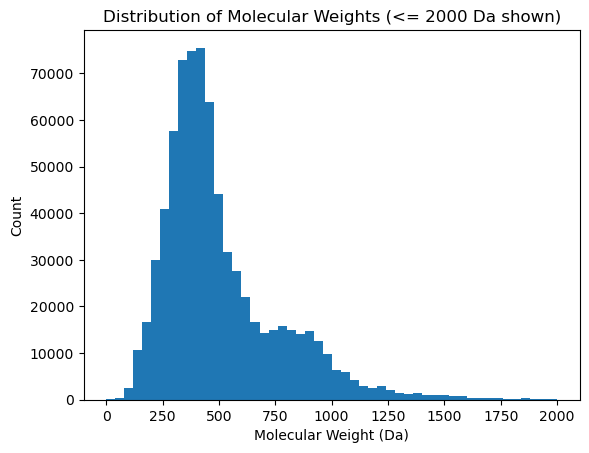

In [9]:
# P0.D Calculate molecular weight and show distribution from SMILES using RDKit
if not SKIP_COCONUT_LOADING:
    def safe_mw(smi):
        """
        Parse SMILES string into an RDKit molecule 'mol' and calculates average molecular weight
        Returns None if SMILES is invalid.
        """
        # Turn 
        mol = Chem.MolFromSmiles(smi)       
        if mol is not None:
            return Descriptors.MolWt(mol)   # Compute average molecular weight (from all isotopes)
        return None

    print("Computing molecular weights (safe)...")

    # Compute MW safely and add to Pandas dataframe 'df' as new column 'MW'
    df['MW'] = df['canonical_smiles'].apply(safe_mw)

    # Count invalid molecules
    invalid_count = df['MW'].isna().sum()
    print(f"Invalid molecules (failed parsing): {invalid_count}")

    # Drop invalid rows
    df = df.dropna(subset=['MW'])

    print(f"Dataset size after cleaning: {len(df)}")

    # Summary statistics
    print("\nMolecular Weight Summary:")
    print(df['MW'].describe())

    # Histogram
    plt.hist(df['MW'], bins=50, range=(0, 2000))
    plt.xlabel("Molecular Weight (Da)")
    plt.ylabel("Count")
    plt.title("Distribution of Molecular Weights (<= 2000 Da shown)")
    plt.show()


### Obtain Rapamycin SMILES structure (MAY NOT BE REQUIRED)

1. Pubchem: https://pubchem.ncbi.nlm.nih.gov/compound/5284616
2. Download SDF file
3. Rename as rapamycin.sdf in notebook folder
4. Read in molecule and verify number of atoms (65) and MW (~914 Da)

In [10]:
# NOT NEEDED BUT INCLUDED AS SANITY CHECK
# P0.DE Rapamycin SMILES Data

supplier = Chem.SDMolSupplier("rapamycin.sdf")
rapa_mol = supplier[0]
assert rapa_mol is not None
print("Atoms:", rapa_mol.GetNumAtoms())
print("MolWt:", Descriptors.MolWt(rapa_mol))


Atoms: 65
MolWt: 914.1869999999998


### Phase 1: Characterize Rapamycin Binding Fragment and Candidate Molecules, Morgan Fingerprints and Similary Scoring

In [22]:
# P1.A Load FKBP12-rapamycin structure (CIF file)

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("FKBP12_RAPA", "1FKB.cif")

In [23]:
# P1.B Inspect structure
model = structure[0]

print("Structure loaded:", structure)

print("\nChains:")
for chain in model:
    print("Chain ID:", chain.id)

print("\nLigands:")
for chain in model:
    for residue in chain:
        if residue.id[0] != " ":
            print(
                "Chain:", chain.id,
                "Ligand:", residue.resname,
                "Residue ID:", residue.id
            )

Structure loaded: <Structure id=FKBP12_RAPA>

Chains:
Chain ID: A

Ligands:
Chain: A Ligand: RAP Residue ID: ('H_RAP', 108, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 109, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 110, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 111, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 112, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 113, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 114, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 115, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 116, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 117, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 118, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 119, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 120, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 121, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 122, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 123, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 124, ' ')
Chain: A Ligand: HOH Residue ID: ('W', 125, ' ')
Chain: A Ligand: HOH Residue ID: ('W',

In [24]:
# P1.C Identify contact atoms (3.5 Angstrom)
atoms = list(structure.get_atoms())
ns = NeighborSearch(atoms)

contact_atoms = set()

for chain in model:
    for residue in chain:
        if residue.resname == "RAP":
            for lig_atom in residue:

                neighbors = ns.search(lig_atom.coord, 3.5)

                for prot_atom in neighbors:
                    if (
                        prot_atom.parent.resname != "RAP"
                        and prot_atom.parent.resname != "HOH"
                    ):
                        contact_atoms.add(lig_atom)
                        break

print("Contact atoms:", len(contact_atoms))

Contact atoms: 20


In [25]:
# P1.D Build interaction map (3.5 Angstrom)
interaction_map = []

for lig_atom in contact_atoms:

    neighbors = ns.search(lig_atom.coord, 3.5)

    for prot_atom in neighbors:

        if (
            prot_atom.parent.resname != "RAP"
            and prot_atom.parent.resname != "HOH"
        ):
            interaction_map.append(
                (
                    lig_atom.serial_number,
                    lig_atom.name,
                    prot_atom.parent.resname,
                    prot_atom.parent.id[1],
                    prot_atom.name
                )
            )

print("Total interactions:", len(interaction_map))

Total interactions: 40


In [26]:
# P1.E Classify interactions
hydrophobic_residues = {
    "PHE","TRP","LEU","ILE","VAL","MET","ALA","PRO"
}

polar_residues = {
    "SER","THR","ASN","GLN","TYR","HIS"
}

hbond_interactions = []
hydrophobic_interactions = []
polar_interactions = []

for entry in interaction_map:

    lig_serial, lig_atom, prot_res, prot_res_id, prot_atom = entry

    if lig_atom[0] in ["O","N"] and prot_atom[0] in ["O","N"]:
        hbond_interactions.append(entry)

    elif lig_atom[0] == "C" and prot_res in hydrophobic_residues:
        hydrophobic_interactions.append(entry)

    elif lig_atom[0] in ["O","N"] and prot_res in polar_residues:
        polar_interactions.append(entry)

print("HBonds:", len(hbond_interactions))
print("Hydrophobic:", len(hydrophobic_interactions))
print("Polar:", len(polar_interactions))

HBonds: 8
Hydrophobic: 1
Polar: 3


In [27]:
# P1.F Extract rapamycin pharmacophore atoms
pharmacophore_atoms = set()

for group in [hbond_interactions, hydrophobic_interactions, polar_interactions]:
    for entry in group:
        lig_serial = entry[0]

        for atom in contact_atoms:
            if atom.serial_number == lig_serial:
                pharmacophore_atoms.add(atom)

print("Pharmacophore atoms:", len(pharmacophore_atoms))


Pharmacophore atoms: 10


In [28]:
# P1.G Load full structure in RDKit (PDB file)

full_structure = Chem.MolFromPDBFile(
    "1FKB.pdb",
    removeHs=False
)

print("Loaded:", full_structure is not None)
print("Atoms:", full_structure.GetNumAtoms())

Loaded: True
Atoms: 1222


In [29]:
# P1.H Identify rapamycin atoms in RDKit
rapa_atom_indices = []

for atom in full_structure.GetAtoms():
    info = atom.GetPDBResidueInfo()

    if info is not None:
        if info.GetResidueName().strip() == "RAP":
            rapa_atom_indices.append(atom.GetIdx())

print("Rapamycin atoms:", len(rapa_atom_indices))

Rapamycin atoms: 68


In [30]:
# P1.I Map pharmacophore atoms to RDKit indices
rdkit_pharmacophore_indices = []

for atom in full_structure.GetAtoms():
    info = atom.GetPDBResidueInfo()
    if info is None:
        continue
    if info.GetResidueName().strip() != "RAP":
        continue
    rdkit_name = info.GetName().strip()
    for bio_atom in pharmacophore_atoms:
        if bio_atom.name.strip() == rdkit_name:
            rdkit_pharmacophore_indices.append(atom.GetIdx())
            break

print("Mapped pharmacophore atoms:", len(rdkit_pharmacophore_indices))

Mapped pharmacophore atoms: 10


In [31]:
# P1.J Extract binding fragment from rapamycin binding region
binding_fragment = Chem.PathToSubmol(
    full_structure,
    rdkit_pharmacophore_indices
)

# Sanity checks
print("Fragment atoms:", binding_fragment.GetNumAtoms())
from rdkit import Chem

print(Chem.MolToSmiles(binding_fragment))

Fragment atoms: 15
CC.CC.CC=O.CCC.NCC(N)=O


In [32]:
# P1.K Sanitize fragment
# RDKit validates and updates a molecule's structure by calculating aromaticity, checking valencies, and setting 
# hybridization. It ensures the molecule is chemically valid.

rdmolops.SanitizeMol(binding_fragment)

rdkit.Chem.rdmolops.SanitizeFlags.SANITIZE_NONE

In [33]:
# P1.L Load Coconut Dataset
SKIP_COCONUT_LOADING = True

if not SKIP_COCONUT_LOADING:

    # Load dataset (make sure file is in same directory)
    coconut = pd.read_csv("coconut_csv-04-2026.csv")

    # Keep only SMILES, name, identifier
    #coconut = coconut[["canonical_smiles"]].dropna()
    coconut = coconut[[
        "canonical_smiles",
        "name",
        "identifier"
    ]].dropna(subset=["canonical_smiles"])


    # Rename column for consistency
    coconut.rename(columns={"canonical_smiles": "smiles"}, inplace=True)

    print("Initial dataset size:", len(coconut))
    print(coconut.columns)
    print(coconut.head())

/var/folders/_l/vlm5pys14pq7q19wh7lzcbf40000gn/T/ipykernel_2038/2760181775.py:4: DtypeWarning: Columns (0: np_classifier_is_glycoside) have mixed types. Specify dtype option on import or set low_memory=False.
  coconut = pd.read_csv("coconut_csv-04-2026.csv")


Initial dataset size: 738827
Index(['smiles', 'name', 'identifier'], dtype='str')
                                              smiles  \
0  CC[C@H](C)[C@@H]1NC(=O)[C@H](C)NC(=O)[C@H](C)N...   
1  C=C1[C@@H]2C[C@H](OC(C)=O)[C@@H]3[C@@](CC(=O)[...   
2  CC(C)[C@H]1CC[C@H]([C@@]2(O)CC[C@H]3[C@@H]4CCC...   
3  CC(=O)O[C@H]1C[C@@]2(C)C(=O)CCC(C)=C2[C@H]2OC(...   
4  COC(=O)/C(=C/C1=CC=C(OC)C=C1)C1=C(OC)C=C2O[C@@...   

                                                name    identifier  
0                                      Cycloviolin D  CNP0581134.2  
1                                                NaN  CNP0114775.1  
2                                  Anastomosacetal A  CNP0030601.2  
3                                                NaN  CNP0330217.1  
4  methyl (~{E})-3-(4-methoxyphenyl)-2-[(2~{R})-2...  CNP0298424.2  


In [ ]:
# P1.M Convert SMILES to RDKit molecules (with optional skip)

PICKLE_PATH = "rdkit_coconut_molecules.pkl"
REBUILD_MOLECULES = False   # True = recompute from SMILES and overwrite pickle
                            # False = load from pickle if it exists
SKIP_MOLECULES_LOADING = True  # True = skip loading/building molecules in this cell
                               #       (use filtered cache in next cell)
                               # False = load rebuilt molecules 

if SKIP_MOLECULES_LOADING:
    print("Skipping molecule cache load/build in this cell.")
    print("Filtered cache can be loaded in the next prefilter cell.")
    molecules = None
elif not REBUILD_MOLECULES:
    print(f"Loading cached molecules from {PICKLE_PATH} ...")
    with open(PICKLE_PATH, "rb") as f:
        molecules = pickle.load(f)
    print(f"Loaded {len(molecules)} molecules from cache.")
else:
    print("Converting SMILES to RDKit molecules...")
    molecules = []
    invalid_mols = 0

    for _, row in tqdm(coconut.iterrows(), total=len(coconut)):
        smi = row["smiles"]
        mol = Chem.MolFromSmiles(smi)

        if mol is not None:
            molecules.append((smi, mol, row["name"], row["identifier"]))
        else:
            invalid_mols += 1

    print("Valid molecules:", len(molecules))
    print(f"Invalid SMILES skipped: {invalid_mols}")

    print(f"Saving cache to {PICKLE_PATH} ...")

    # Save file with HIGHEST_PROTOCOL (most efficient/compact binary form)
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(molecules, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Cache saved.")

Loading cached molecules from rdkit_coconut_molecules.pkl ...
Loaded 738823 molecules from cache.


In [41]:
# P1.N Prefilter Coconut database
"""
# Run diagnostic to determine the breakdown of filter parameters in the dataset

RUN_PREFILTER = False

if RUN_PREFILTER:
    counts = {
        "total": 0,
        "mw": 0,
        "hba": 0,
        "hbd": 0,
        "logp": 0,
        "rings": 0,
        "tpsa": 0,
        "final": 0
    }


    for smi, mol, name, cid in molecules:
        counts["total"] += 1

        mw = Descriptors.MolWt(mol)
        counts["mw"] += 1

        hba = Descriptors.NumHAcceptors(mol)
        counts["hba"] += 1

        hbd = Descriptors.NumHDonors(mol)
        counts["hbd"] += 1

        logp = Crippen.MolLogP(mol)
        counts["logp"] += 1

        rings = Descriptors.RingCount(mol)
        counts["rings"] += 1

        tpsa = Descriptors.TPSA(mol)
        counts["tpsa"] += 1

        counts["final"] += 1

    print(counts)
"""

{'total': 738823, 'mw': 738823, 'hba': 738823, 'hbd': 738823, 'logp': 738823, 'rings': 738823, 'tpsa': 738823, 'final': 738823}


In [ ]:
# P1.N Prefilter Coconut database
# Run diagnostic to determine the breakdown of filter parameters in the dataset
"""
counts = {
    "total": 0,
    "mw": 0,
    "hba": 0,
    "hbd": 0,
    "logp": 0,
    "rings": 0,
    "tpsa": 0,
    "final": 0
}


for smi, mol, name, cid in molecules:
    counts["total"] += 1

    mw = Descriptors.MolWt(mol)
    if not (300 < mw < 800):
        continue
    counts["mw"] += 1

    hba = Descriptors.NumHAcceptors(mol)
    if not (2 <= hba <= 10):
        continue
    counts["hba"] += 1

    hbd = Descriptors.NumHDonors(mol)
    if not (1 <= hbd <= 5):
        continue
    counts["hbd"] += 1

    logp = Crippen.MolLogP(mol)
    if not (1 < logp < 6):
        continue
    counts["logp"] += 1

    rings = Descriptors.RingCount(mol)
    if not (1 <= rings <= 6):
        continue
    counts["rings"] += 1

    tpsa = Descriptors.TPSA(mol)
    if tpsa > 150:
        continue
    counts["tpsa"] += 1

    counts["final"] += 1

print(counts)
"""

{'total': 738823, 'mw': 507090, 'hba': 433489, 'hbd': 324383, 'logp': 250247, 'rings': 235699, 'tpsa': 226367, 'final': 226367}


In [42]:
# P1.N Prefilter Coconut dataset molecules (cont.)
# Adjust filtering based on filtering counts from above (226,367 molecules)

PICKLE_PATH_FILTERED = "rdkit_coconut_molecules_filtered.pkl"
REBUILD_MOLECULES_FILTERED = False   # True = recompute from RDKit molecules and overwrite pickle
                                     # False = load from pickle if it exists

FILTERS = {
    "mw_min": 350,
    "mw_max": 700,
    "hba_min": 3,
    "hba_max": 8,
    "hbd_min": 1,
    "hbd_max": 4,
    "logp_min": 2,
    "logp_max": 5,
    "rings_min": 2,
    "rings_max": 5,
    "tpsa_max": 150
}

if not REBUILD_MOLECULES_FILTERED and os.path.exists(PICKLE_PATH_FILTERED):
    print(f"Loading cached filtered molecules from {PICKLE_PATH_FILTERED} ...")
    with open(PICKLE_PATH_FILTERED, "rb") as f:
        filtered = pickle.load(f)
    print(f"Loaded {len(filtered)} filtered molecules from cache.")
else:
    if molecules is None:
        raise ValueError(
            "molecules is None. Set SKIP_MOLECULES_LOADING = False in the previous cell "
            "or set REBUILD_MOLECULES_FILTERED = False with an existing filtered pickle."
        )

    print("Running prefilter...")
    filtered = []

    #for smi, mol in molecules:
    for smi, mol, name, cid in tqdm(molecules, total=len(molecules)):
        try:
            mw = Descriptors.MolWt(mol)
            hba = Descriptors.NumHAcceptors(mol)
            hbd = Descriptors.NumHDonors(mol)
            logp = Crippen.MolLogP(mol)
            rings = Descriptors.RingCount(mol)
            tpsa = Descriptors.TPSA(mol)

            # Apply filters
            if not (FILTERS["mw_min"] < mw < FILTERS["mw_max"]):
                continue
            if not (FILTERS["hba_min"] <= hba <= FILTERS["hba_max"]):
                continue
            if not (FILTERS["hbd_min"] <= hbd <= FILTERS["hbd_max"]):
                continue
            if not (FILTERS["logp_min"] < logp < FILTERS["logp_max"]):
                continue
            if not (FILTERS["rings_min"] <= rings <= FILTERS["rings_max"]):
                continue
            if tpsa > FILTERS["tpsa_max"]:
                continue

            #filtered.append((smi, mol))
            filtered.append((smi, mol, name, cid))
        except:
            continue

    print(f"Saving filtered cache to {PICKLE_PATH_FILTERED} ...")
    with open(PICKLE_PATH_FILTERED, "wb") as f:
        pickle.dump(filtered, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("Cache saved.")

print("Filtered molecules:", len(filtered))

Running prefilter...


100%|██████████| 738823/738823 [01:31<00:00, 8110.32it/s] 


Saving filtered cache to rdkit_coconut_molecules_filtered.pkl ...
Cache saved.
Filtered molecules: 96682


* Note on filtering: Descriptor availability was used as a filtering criterion, which may bias the dataset toward well-characterized molecules. Future work could recompute all descriptors directly from SMILES molecular structures to avoid exclusion due to missing values and expand coverage of chemical space.

Start: ~738K molecules
Filter on properties (mw, hba, hbd, logp, rings, tpsa): ~97K molecules pass

These features are derived, not measured, so cannot be imputed. These are drug-like / rapamycin-like molecule attributes
 - MW → from structure
 - HBA/HBD → from structure
 - TPSA → from structure
 - logP → computed
 - rings → computed

In [43]:
# P1.O Create morgan fingerprint function

# Define fingerprint function
def get_fp_from_mol(mol, radius):
    return AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        2048,
        useFeatures=True 
    )


In [44]:
# P1.P Calculate rapamycin binding fragment morgan fingerprint
# Precompute query fingerprints (using radius = 1 and 2) from rapamycin binding fragement
from rdkit.Chem import AllChem

# Morgan fingerprint from rapamycin binding fragment (radius=1 and 2)
binding_fp_r1 = get_fp_from_mol(binding_fragment, 1)    
binding_fp_r2 = get_fp_from_mol(binding_fragment, 2)

print("Binding FP bits:",
      binding_fp_r1.GetNumOnBits(),
      binding_fp_r2.GetNumOnBits())

Binding FP bits: 12 13


In [45]:
# P1.Q Compute candidate molecule morgan fingerprint and similarity scores 
# Benchmark small batch based (time) (using radius = 2)

test_batch = filtered[:1000]
start = time.time()

for smi, mol, name, cid in test_batch:
    fp = get_fp_from_mol(mol, 2)

end = time.time()

print("Time for 1000 molecules:", end - start, "seconds")

Time for 1000 molecules: 0.3071630001068115 seconds


In [46]:
# P1.Q Compute candidate molecule morgan fingerprint and similarity scores
from rdkit.Chem import DataStructs

batch_size = 2000
results = []

for i in range(0, len(filtered), batch_size):

    batch = filtered[i:i+batch_size]

    for smi, mol, name, cid in batch:
        try:
            fp_r1 = get_fp_from_mol(mol, 1)
            fp_r2 = get_fp_from_mol(mol, 2)

            # Tanimoto
            tan_r1 = DataStructs.TanimotoSimilarity(binding_fp_r1, fp_r1)
            tan_r2 = DataStructs.TanimotoSimilarity(binding_fp_r2, fp_r2)
            sim_tanimoto = max(tan_r1, tan_r2)

            # Tversky (symmetric (alpha=beta=0.5)
            alpha = 0.5
            beta = 0.5
            tv_sym_r1 = DataStructs.TverskySimilarity(
                binding_fp_r1, fp_r1, alpha, beta
            )
            tv_sym_r2 = DataStructs.TverskySimilarity(
                binding_fp_r2, fp_r2, alpha, beta
            )
            sim_tv_sym = max(tv_sym_r1, tv_sym_r2)

            # Tversk (fragment-focused (alpha=0.1, beta=0.9)) 
            alpha = 0.1
            beta = 0.9
            tv_frag_r1 = DataStructs.TverskySimilarity(
                binding_fp_r1, fp_r1, alpha, beta
            )
            tv_frag_r2 = DataStructs.TverskySimilarity(
                binding_fp_r2, fp_r2, alpha, beta
            )
            sim_tv_frag = max(tv_frag_r1, tv_frag_r2)

            results.append({
                "smiles": smi,
                "name": name,
                "coconut_id": cid,
                "sim_tanimoto": sim_tanimoto,
                "sim_r1_tan": tan_r1,
                "sim_r2_tan": tan_r2,
                "sim_tv_sym": sim_tv_sym,
                "sim_r1_tv_sym": tv_sym_r1,
                "sim_r2_tv_sym": tv_sym_r2,
                "sim_tv_frag": sim_tv_frag,
                "sim_r1_tv_frag": tv_frag_r1,
                "sim_r2_tv_frag": tv_frag_r2
            })


        except:
            continue

    print(f"Processed {i + len(batch)} / {len(filtered)}")


Processed 2000 / 96682
Processed 4000 / 96682
Processed 6000 / 96682
Processed 8000 / 96682
Processed 10000 / 96682
Processed 12000 / 96682
Processed 14000 / 96682
Processed 16000 / 96682
Processed 18000 / 96682
Processed 20000 / 96682
Processed 22000 / 96682
Processed 24000 / 96682
Processed 26000 / 96682
Processed 28000 / 96682
Processed 30000 / 96682
Processed 32000 / 96682
Processed 34000 / 96682
Processed 36000 / 96682
Processed 38000 / 96682
Processed 40000 / 96682
Processed 42000 / 96682
Processed 44000 / 96682
Processed 46000 / 96682
Processed 48000 / 96682
Processed 50000 / 96682
Processed 52000 / 96682
Processed 54000 / 96682
Processed 56000 / 96682
Processed 58000 / 96682
Processed 60000 / 96682
Processed 62000 / 96682
Processed 64000 / 96682
Processed 66000 / 96682
Processed 68000 / 96682
Processed 70000 / 96682
Processed 72000 / 96682
Processed 74000 / 96682
Processed 76000 / 96682
Processed 78000 / 96682
Processed 80000 / 96682
Processed 82000 / 96682
Processed 84000 / 96

* Note Tversky similarity is found by sim = |A ∩ B| / (|A ∩ B| + α|A − B| + β|B − A|)
  - A - B (fragement features missing in molecule)
  - B - A (extra features in molecule) 
  - α=0.5, β=0.5 suggests 'symmetric error weighting'
  - α=0.1, β=0.9 suggests 'fragment containment' (does the candidate contain all the required features without penalizing for extra features)

In [47]:
# P1.R Rank candidates (Tanimoto and Tversky)

# Create pandas dataframe from results
results_df = pd.DataFrame(results)

# Remove duplicates
results_df = results_df.drop_duplicates(subset=["smiles"])

# Fill in missing names
results_df["name"] = results_df["name"].fillna(results_df["coconut_id"])

# View subset
print("All results columns:")
print(results_df.columns)

print("\nAll results example:")
print(results_df.head())


# Tanimoto results (sorted) 
top_tanimoto = results_df.sort_values(by="sim_tanimoto", ascending=False)
top_tan_r1 = results_df.sort_values(by="sim_r1_tan", ascending=False)
top_tan_r2 = results_df.sort_values(by="sim_r2_tan", ascending=False)

# Tversky results (sorted)
# Symmetric (alpha=beta=0.5)
top_tv_sym   = results_df.sort_values(by="sim_tv_sym", ascending=False)
top_tv_r1_sym   = results_df.sort_values(by="sim_r1_tv_sym", ascending=False)
top_tv_r2_sym   = results_df.sort_values(by="sim_r2_tv_sym", ascending=False)

#Fragment-focused (alpha=0.1, beta=0.9)
top_tv_frag  = results_df.sort_values(by="sim_tv_frag", ascending=False)
top_tv_r1_frag   = results_df.sort_values(by="sim_r1_tv_frag", ascending=False)
top_tv_r2_frag   = results_df.sort_values(by="sim_r2_tv_frag", ascending=False)


# Print Tanimoto stats
print("\nTanimoto stats (combined):")
print(results_df["sim_tanimoto"].describe())
print("\nTanimoto stats (Radius=1):")
print(results_df["sim_r1_tan"].describe())
print("\nTanimoto stats (Radius=2):")
print(results_df["sim_r2_tan"].describe())

# Print Tversky stats
# Balanced stats
print("\nTversky balanced (alpha=beta=0.5) stats (combined):")
print(results_df["sim_tv_sym"].describe())
print("\nTversky balanced (alpha=beta=0.5) stats (Radius=1):")
print(results_df["sim_r1_tv_sym"].describe())
print("\nTversky balanced (alpha=beta=0.5) stats (Radius=2):")
print(results_df["sim_r2_tv_sym"].describe())

# Fragment-focused stats
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (combined):")
print(results_df["sim_tv_frag"].describe())
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (Radius=1):")
print(results_df["sim_r1_tv_frag"].describe())
print("\nTversky fragment-focused (alpha=0.1, beta=0.9) stats (Radius=2):")
print(results_df["sim_r2_tv_frag"].describe())

# Print top hits results
print("\nTop hits (Tanimoto (combined)):")
for _, row in top_tanimoto.head(5).iterrows():
    print(row["sim_tanimoto"], row["name"], row["smiles"])

print("\nTop hits (Tanimoto (Radius=1)):")
for _, row in top_tan_r1.head(5).iterrows():
    print(row["sim_r1_tan"], row["name"])

print("\nTop hits (Tanimoto (Radius=2)):")
for _, row in top_tan_r2.head(5).iterrows():
    print(row["sim_r2_tan"], row["name"])
    
print("\nTop hits (Tversky symmetric (combined)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky symmetric (Radius=1)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r1_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky symmetric (Radius=2)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r2_tv_sym"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (combined)):")
for _, row in top_tv_frag.head(5).iterrows():
    print(row["sim_tv_frag"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (Radius=1)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r1_tv_frag"], row["name"], row["smiles"])

print("\nTop hits (Tversky fragment-focused (Radius=2)):")
for _, row in top_tv_sym.head(5).iterrows():
    print(row["sim_r2_tv_frag"], row["name"], row["smiles"])



All results columns:
Index(['smiles', 'name', 'coconut_id', 'sim_tanimoto', 'sim_r1_tan',
       'sim_r2_tan', 'sim_tv_sym', 'sim_r1_tv_sym', 'sim_r2_tv_sym',
       'sim_tv_frag', 'sim_r1_tv_frag', 'sim_r2_tv_frag'],
      dtype='str')

All results example:
                                              smiles               name  \
0  CC(C)[C@H]1CC[C@H]([C@@]2(O)CC[C@H]3[C@@H]4CCC...  Anastomosacetal A   
1  CC(C)C1=C(O)C(O)=C2C[C@]34CCC[C@](C)(C(=O)O3)[...       CNP0233224.2   
2  C=C1CC[C@H]2[C@](C)(CCC[C@]2(C)C(=O)OC)[C@H]1C...       CNP0306468.5   
3  C=C(C)[C@@H]1CC[C@@H](C)[C@@]2(O)[C@@H]1C=C(C)...    Fischerindoline   
4  C=C(C(=O)O)C1CCC(C)C2=C1C(=CC=CC1=CC(OC)=C(O)C...       CNP0606920.0   

     coconut_id  sim_tanimoto  sim_r1_tan  sim_r2_tan  sim_tv_sym  \
0  CNP0030601.2      0.217391    0.217391    0.113636    0.357143   
1  CNP0233224.2      0.200000    0.200000    0.116279    0.333333   
2  CNP0306468.5      0.200000    0.200000    0.113208    0.333333   
3  CNP0205024.

In [48]:
results_df.describe()

,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag
count,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000,96682.000000
mean,0.193755,0.193744,0.112266,0.320702,0.320684,0.200575,0.265119,0.265116,0.142461
std,0.057559,0.057580,0.029883,0.081325,0.081364,0.048227,0.072868,0.072874,0.035747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.156250,0.156250,0.093023,0.270270,0.270270,0.170213,0.218579,0.218579,0.119617
50%,0.200000,0.200000,0.113208,0.333333,0.333333,0.203390,0.265152,0.265152,0.143541
75%,0.230769,0.230769,0.130435,0.375000,0.375000,0.230769,0.319635,0.319635,0.164835
max,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540


In [49]:
# Troubleshooting step
print("Binding fragment bits:",
      binding_fp_r1.GetNumOnBits(),
      binding_fp_r2.GetNumOnBits())

Binding fragment bits: 12 13


*Note from above that radius = 1 outperforms radius = 2 for morgan fingerprints

In [50]:
# Closer look a top hits
top_tv_frag.head(10)

,smiles,name,coconut_id,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag
82691,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,CNP0124018.1,CNP0124018.1,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540
10029,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,Fenestin A,CNP0537257.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500
28651,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,Fenestin B,CNP0551128.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500
4380,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,NCGC00398625-01,CNP0442869.1,0.500000,0.500000,0.258065,0.666667,0.666667,0.410256,0.666667,0.666667,0.323887
24814,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,CNP0123277.2,CNP0123277.2,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535
57099,CC1(C)[C@@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(...,CNP0374427.1,CNP0374427.1,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694
85452,CC(=O)N1CCC(NC[C@H]2[C@@H]3CC(=O)N(C4CCCCC4)[C...,CNP0578148.1,CNP0578148.1,0.437500,0.437500,0.250000,0.608696,0.608696,0.400000,0.630631,0.630631,0.312500
8724,CC1(C)[C@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(=...,CNP0374427.2,CNP0374427.2,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694
85204,CC(=O)NC1=CC=C(NC(=O)CCCCC(=O)NC2=CC=C(NC(C)=O...,"N,N'-bis[4-(acetylamino)phenyl]hexanediamide",CNP0560921.0,0.437500,0.437500,0.291667,0.608696,0.608696,0.451613,0.630631,0.630631,0.400000
11848,CC1(C)[C@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(C...,CNP0123277.1,CNP0123277.1,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535


* Initial interpretation:
radius 1 > radius 2 results (Tanimoto and Tversky)
  - Radius 1: Local features /functional groups dominate (e.g. H-bonds, small motifs)
  - Radius 2: Extended scaffold less important
Max value (Tanimoto): 0.50
Max value (Tversky): 0.78

Tversky similarity improved fragment recognition,
revealing enrichment of amide-containing and hydrophobic scaffolds
consistent with FKBP12 binding features.

U. Compare top hits based on Tanimoto and Tversky
  - Scatter plot
  - Correlation
  - Interpretation
  - Top hit overlap
  - Rank correlation
  - Identify disagreement molecules
  - Histogram comparison

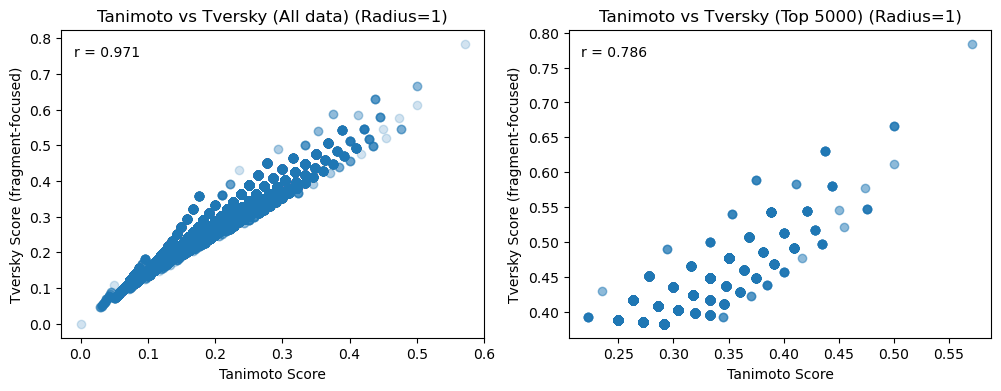

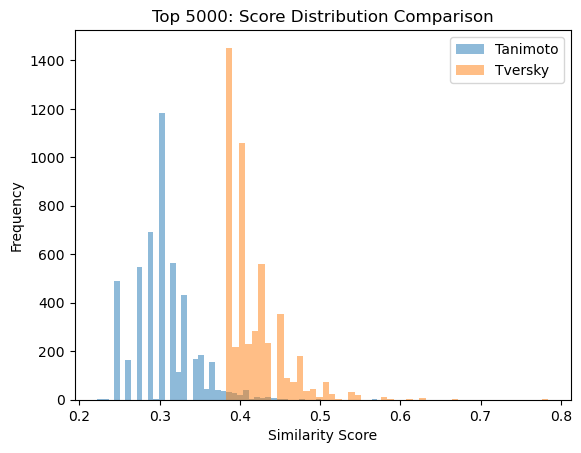

In [51]:
# P1.S Compare Tanimoto and Tversky Similarity

# Top 5000 hits
results_df_top = results_df.sort_values(by="sim_tv_frag", ascending=False).head(5000).copy()

# Correlations to display on plots
corr_all = results_df["sim_r1_tan"].corr(results_df["sim_r1_tv_frag"])
corr_top = results_df_top["sim_r1_tan"].corr(results_df_top["sim_r1_tv_frag"])

# Scatterplot comparing similarity scoring (all data and top 5000 hits)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

# All data
plt.subplot(1,2,1)
plt.scatter(results_df["sim_r1_tan"], results_df["sim_r1_tv_frag"], alpha=0.2)
plt.title("Tanimoto vs Tversky (All data) (Radius=1)")
plt.xlabel("Tanimoto Score")
plt.ylabel("Tversky Score (fragment-focused)")
plt.text(
    0.03, 0.95, f"r = {corr_all:.3f}",
    transform=axes[0].transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

# Top 5000 subset
plt.subplot(1,2,2)
plt.scatter(results_df_top["sim_r1_tan"], results_df_top["sim_r1_tv_frag"], alpha=0.5)
plt.title("Tanimoto vs Tversky (Top 5000) (Radius=1)")
plt.xlabel("Tanimoto Score")
plt.ylabel("Tversky Score (fragment-focused)")
plt.text(
    0.03, 0.95, f"r = {corr_top:.3f}",
    transform=axes[1].transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.show()


# Disagreement molecules (biggest difference between Tanimoto and Tversky)
results_df["diff"] = results_df["sim_r1_tv_frag"] - results_df["sim_r1_tan"]
results_df.sort_values("diff", ascending=False).head(10)


# Histogram (top 5000 hits only)
plt.figure()

plt.hist(results_df_top["sim_r1_tan"], bins=50, alpha=0.5, label="Tanimoto")
plt.hist(results_df_top["sim_r1_tv_frag"], bins=50, alpha=0.5, label="Tversky")

plt.legend()
plt.title("Top 5000: Score Distribution Comparison")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

* We compared Tanimoto and Tversky similarity metrics across the full dataset and a high-scoring subset candidates ranked by fragment-focused Tversky similarity to ensure both statistical robustness and enrichment for chemically relevant structures. While the metrics were highly correlated across all molecules (r = 0.97), this correlation decreased substantially among top 5000 candidates (r = 0.79), indicating that Tversky captures additional fragment-containment information not reflected in symmetric similarity measures. This supports the use of Tversky similarity for identifying pharmacophore-relevant structures.

Histogram analysis of top candidates shows a rightward shift in Tversky similarity scores compared to Tanimoto, consistent with reduced penalty for additional molecular features and improved sensitivity to fragment containment.


Phase 2: Local Similarity Analysis
A. Select candidates (e.g. top 5000?)
B. Create local similary function (using Tanimoto and Tversky, r1 and r2)
C. Compute local scores (using Tanimoto and Tversky)
D. Combine scores
E. Review results

  

### Phase 2: Local Similarity Analysis

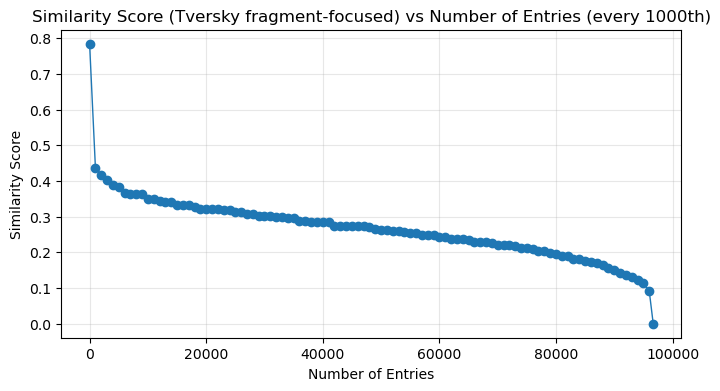

Total ranked entries: 96682
Points plotted (all-ranked): 98 (step=1000)


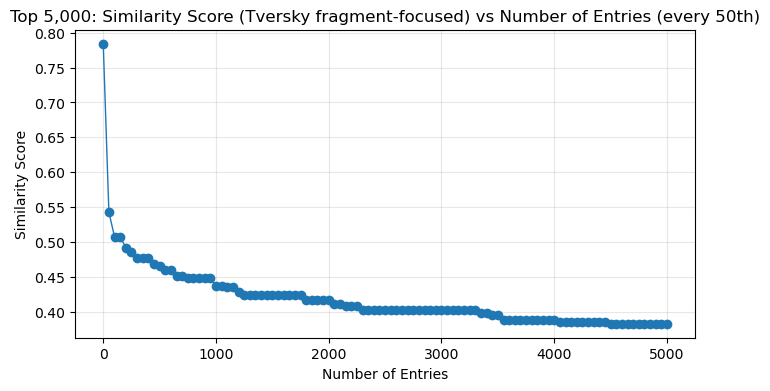

Focused range: top 5000 entries
Points plotted (top-5,000): 101 (step=50)
Subset size: 5000


In [55]:
# P2.A Rank candidates by fragment-focused Tversky and plot score trends

# Rank all candidates by similarity score (highest first)
results_ranked = (
    results_df.sort_values(by="sim_tv_frag", ascending=False)
    .reset_index(drop=True)
    .copy()
)
results_ranked["entry_n"] = np.arange(1, len(results_ranked) + 1)

# Plot 1: all ranked entries, sampled every 1000
plot_step = 1000
plot_df = results_ranked.iloc[::plot_step].copy()

# Include the last entry if it is not already included by stepping
if plot_df.iloc[-1]["entry_n"] != results_ranked.iloc[-1]["entry_n"]:
    plot_df = pd.concat([plot_df, results_ranked.tail(1)], ignore_index=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["entry_n"], plot_df["sim_tv_frag"], marker="o", linewidth=1)
plt.title("Similarity Score (Tversky fragment-focused) vs Number of Entries (every 1000th)")
plt.xlabel("Number of Entries")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.3)
plt.show()

print(f"Total ranked entries: {len(results_ranked)}")
print(f"Points plotted (all-ranked): {len(plot_df)} (step={plot_step})")

# Plot 2: focused on top 5,000, sampled every 50
top_n_focus = 5000
focus_step = 50
results_top_focus = results_ranked.head(top_n_focus).copy()
focus_plot_df = results_top_focus.iloc[::focus_step].copy()

# Include the last top-N entry if not already included
if focus_plot_df.iloc[-1]["entry_n"] != results_top_focus.iloc[-1]["entry_n"]:
    focus_plot_df = pd.concat([focus_plot_df, results_top_focus.tail(1)], ignore_index=True)

plt.figure(figsize=(8, 4))
plt.plot(focus_plot_df["entry_n"], focus_plot_df["sim_tv_frag"], marker="o", linewidth=1)
plt.title("Top 5,000: Similarity Score (Tversky fragment-focused) vs Number of Entries (every 50th)")
plt.xlabel("Number of Entries")
plt.ylabel("Similarity Score")
plt.grid(alpha=0.3)
plt.show()

print(f"Focused range: top {len(results_top_focus)} entries")
print(f"Points plotted (top-5,000): {len(focus_plot_df)} (step={focus_step})")

# Keep top 5000 candidates for downstream Phase 2 cells
results_df_top = results_ranked.head(5000).copy()
print("Subset size:", len(results_df_top))

In [56]:
# P2.B Local similarity function (DID NOT ADD ANY VALUE THUS FAR)

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, DataStructs
from rdkit.Chem.rdmolops import FindAtomEnvironmentOfRadiusN, PathToSubmol

def local_similarity(mol, binding_fp_r1, binding_fp_r2):

    best_tan = 0.0
    best_tv = 0.0

    for atom in mol.GetAtoms():

        for radius in [1, 2]:

            try:
                # Get atom environment
                env = FindAtomEnvironmentOfRadiusN(
                    mol, radius, atom.GetIdx()
                )

                if not env:
                    continue

                # Extract subgraph
                submol = PathToSubmol(mol, env)

                # CRITICAL FIX: Proper sanitization
                try:
                    Chem.SanitizeMol(
                        submol,
                        sanitizeOps=(
                            Chem.SanitizeFlags.SANITIZE_ALL ^
                            Chem.SanitizeFlags.SANITIZE_KEKULIZE
                        )
                    )
                except:
                    continue

                # Skip trivial fragments
                if submol.GetNumAtoms() < 2:
                    continue

                # Generate fingerprint
                fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
                    submol,
                    radius,
                    2048
                )

                # Select correct binding fingerprint
                if radius == 1:
                    binding_fp = binding_fp_r1
                else:
                    binding_fp = binding_fp_r2

                # Similarities
                tan = DataStructs.TanimotoSimilarity(binding_fp, fp)
                tv = DataStructs.TverskySimilarity(binding_fp, fp, 0.1, 0.9)

                # Track best
                best_tan = max(best_tan, tan)
                best_tv = max(best_tv, tv)

            except Exception:
                continue

    return best_tan, best_tv

* Note on local similarity function. We're using radius = 1 and 2 on the local test which may have different results from the entire molecule test performed earlier. 
Radius 1 (very local (~1 bond))
  - Captures
     - functional groups
     - H-bond donors/acceptors
     - immediate pharmacophore features
  - Aligns with binding interactions (often very local)
  - Goes beyond only using radius = 2 which
     -  misses ultra-local matches
     - slightly dilutes pharmacophore signal
     - less sensitive to key binding atoms

Radius 2 (slightly larger (~2 bonds))
  - Captures
     - small substructures
     - ring fragmeents
     - connectivity patterns
  - Aligns with context around pharmacophore
  - Goes beyond only using radius = 1 which
     -  too local
     - can produce false positives
     - ignores structural context

In [57]:
# Debug sanity check (Should not be 0)
mol = Chem.MolFromSmiles(results_df_top.iloc[0]["smiles"])
Chem.SanitizeMol(mol)

local_similarity(mol, binding_fp_r1, binding_fp_r2)

(0.07692307692307693, 0.20833333333333334)

In [58]:
# Use a pretest to check computation time
test_subset = results_df_top.head(200).copy()

import time

start = time.time()

local_tan = []
local_tv = []

# Loop over test_subset only
for i, row in test_subset.iterrows():

    mol = Chem.MolFromSmiles(row["smiles"])

    if mol is None:
        local_tan.append(0.0)
        local_tv.append(0.0)
        continue

    Chem.SanitizeMol(mol)

    sim_tan, sim_tv = local_similarity(
        mol,
        binding_fp_r1,
        binding_fp_r2
    )

    local_tan.append(sim_tan)
    local_tv.append(sim_tv)

end = time.time()

# Print time
elapsed = end - start

print(f"Processed {len(test_subset)} molecules in {elapsed:.2f} seconds")
per_mol = elapsed / len(test_subset)
print(f"Time per molecule: {per_mol:.4f} sec")

# estimate full runtime
estimated = per_mol * len(results_df_top)

print(f"Estimated time for full run: {estimated/60:.2f} minutes")

Processed 200 molecules in 0.48 seconds
Time per molecule: 0.0024 sec
Estimated time for full run: 0.20 minutes


In [59]:
# 2.C Compute both local scores

local_tan = []
local_tv = []

for i, row in results_df_top.iterrows():

    mol = Chem.MolFromSmiles(row["smiles"])

    if mol is None:
        local_tan.append(0.0)
        local_tv.append(0.0)
        continue

    sim_tan, sim_tv = local_similarity(
        mol,
        binding_fp_r1,
        binding_fp_r2
    )

    local_tan.append(sim_tan)
    local_tv.append(sim_tv)

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1} / {len(results_df_top)}")


results_df_top["sim_local_tan"] = local_tan
results_df_top["sim_local_tv"] = local_tv

Processed 500 / 5000
Processed 1000 / 5000
Processed 1500 / 5000
Processed 2000 / 5000
Processed 2500 / 5000
Processed 3000 / 5000
Processed 3500 / 5000
Processed 4000 / 5000
Processed 4500 / 5000
Processed 5000 / 5000


In [60]:
# 2.D Combine scores
results_df_top["sim_v3"] = results_df_top[
    ["sim_tv_frag", "sim_local_tv"]
].max(axis=1)

sim_tv_frag	    (global fragment containment)
sim_local_tv	(local fragment containment)
sim_local_tan	(sanity check / baseline)

If sim_local_tv >> sim_tv_frag, then molecule contains hidden fragment
If sim_tv_frag ≈ sim_local_tv, then globally similar molecule
If sim_local_tan >> sim_local_tv, then similarly dirven by generic structure, not the fragment

In [61]:
# 2.E View results
top_v3 = results_df_top.sort_values(
    by="sim_v3",
    ascending=False
)

top_v3.head(10)

,smiles,name,coconut_id,sim_tanimoto,sim_r1_tan,sim_r2_tan,sim_tv_sym,sim_r1_tv_sym,sim_r2_tv_sym,sim_tv_frag,sim_r1_tv_frag,sim_r2_tv_frag,diff,entry_n,sim_local_tan,sim_local_tv,sim_v3
0,CCCCCC(=O)N1CC[C@@H](CC(=O)N2CCC(C(N)=O)CC2)[C...,CNP0124018.1,CNP0124018.1,0.571429,0.571429,0.346154,0.727273,0.727273,0.514286,0.784314,0.784314,0.426540,0.212885,1,0.076923,0.208333,0.784314
2,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(/O)[C@@...,Fenestin B,CNP0551128.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500,0.166667,3,0.100000,0.212766,0.666667
3,CC(C)NC(=O)N1CCN(C(=O)C2CCCCC2)[C@@H](C(=O)N[C...,NCGC00398625-01,CNP0442869.1,0.500000,0.500000,0.258065,0.666667,0.666667,0.410256,0.666667,0.666667,0.323887,0.166667,4,0.076923,0.208333,0.666667
1,CCC(C)[C@@H]1/N=C(/O)[C@H](CC(C)C)/N=C(\O)[C@@...,Fenestin A,CNP0537257.1,0.500000,0.500000,0.250000,0.666667,0.666667,0.400000,0.666667,0.666667,0.312500,0.166667,2,0.100000,0.212766,0.666667
4,CC1(C)[C@@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(...,CNP0123277.2,CNP0123277.2,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535,0.193131,5,0.066667,0.208333,0.630631
5,CC1(C)[C@@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(...,CNP0374427.1,CNP0374427.1,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694,0.193131,6,0.066667,0.208333,0.630631
6,CC(=O)N1CCC(NC[C@H]2[C@@H]3CC(=O)N(C4CCCCC4)[C...,CNP0578148.1,CNP0578148.1,0.437500,0.437500,0.250000,0.608696,0.608696,0.400000,0.630631,0.630631,0.312500,0.193131,7,0.058824,0.151515,0.630631
7,CC1(C)[C@]2(C(=O)NCCCNC(=O)[C@]34CC[C@](C)(C(=...,CNP0374427.2,CNP0374427.2,0.437500,0.437500,0.269231,0.608696,0.608696,0.424242,0.630631,0.630631,0.362694,0.193131,8,0.066667,0.208333,0.630631
8,CC(=O)NC1=CC=C(NC(=O)CCCCC(=O)NC2=CC=C(NC(C)=O...,"N,N'-bis[4-(acetylamino)phenyl]hexanediamide",CNP0560921.0,0.437500,0.437500,0.291667,0.608696,0.608696,0.451613,0.630631,0.630631,0.400000,0.193131,9,0.000000,0.000000,0.630631
9,CC1(C)[C@]2(C(=O)NCCCCCNC(=O)[C@]34CC[C@](C)(C...,CNP0123277.1,CNP0123277.1,0.437500,0.437500,0.259259,0.608696,0.608696,0.411765,0.630631,0.630631,0.346535,0.193131,10,0.066667,0.208333,0.630631


In [62]:
# Debug
print(results_df_top[["sim_local_tan", "sim_local_tv", "sim_v3"]].describe())

       sim_local_tan  sim_local_tv       sim_v3
count    5000.000000   5000.000000  5000.000000
mean        0.067477      0.172031     0.416294
std         0.019978      0.049756     0.035830
min         0.000000      0.000000     0.382514
25%         0.058824      0.151515     0.387597
50%         0.066667      0.165289     0.402299
75%         0.076923      0.208333     0.424242
max         0.107143      0.256410     0.784314


In [63]:
# Debug (Should be ~10-20)
print(binding_fp_r1.GetNumOnBits(), binding_fp_r2.GetNumOnBits())

12 13


In [64]:
# Debug sanity check (Should not be 0)
mol = Chem.MolFromSmiles(results_df_top.iloc[0]["smiles"])
Chem.SanitizeMol(mol)

local_similarity(mol, binding_fp_r1, binding_fp_r2)

(0.07692307692307693, 0.20833333333333334)

In [65]:
# Debug
mol = Chem.MolFromSmiles(results_df_top.iloc[0]["smiles"])

print("Mol atoms:", mol.GetNumAtoms())

for atom in mol.GetAtoms():
    env_fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, 2, 2048, fromAtoms=[atom.GetIdx()]
    )
    print(env_fp.GetNumOnBits())
    break

Mol atoms: 27
3


Results above indicates 
- Tversky (global) already detects the relevant fragments
- Local matching is weaker (sim_local_tv ≈ 0.2), suggesting the fragment is distributed across the molecule
NOT localized in a single compact subgraph
- Local matching adds little new information (no re-ranking, no new hits, no score improvements)
- Strong global fragment similarity and weak localized “single patch” match
- Binding motif is NOT a single tight fragment, it is distributed across multiple regions
- Local matching confirmed that the prior matching of full candidate structures was sufficient

Local substructure matching (Phase 2) did not significantly alter candidate rankings compared to fragment-weighted Tversky
similarity, indicating that relevant pharmacophore features are distributed across the molecular scaffold rather than localized in discrete substructures.

### Phase 3: Feature Clustering

In [67]:
# P3.A Input data

df = results_df_top.copy()  # Using data from earlier section of top hits (5000)

df_1000 = df.sample(1000, random_state=42)
df_5000 = df.copy()

In [68]:
# P3.B Feature Extraction

def extract_features_safe(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        Chem.SanitizeMol(mol)

        return {
            "hbd": rdMolDescriptors.CalcNumHBD(mol),
            "hba": rdMolDescriptors.CalcNumHBA(mol),
            "rings": rdMolDescriptors.CalcNumRings(mol),
            "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "tpsa": Descriptors.TPSA(mol),
            "logp": Descriptors.MolLogP(mol),
            "mw": Descriptors.MolWt(mol),
            "amide": Fragments.fr_amide(mol),
        }

    except:
        return None

In [69]:
# P3.C Build Feature Dataframe
def build_feature_df(df_input):
    rows = []

    for _, row in df_input.iterrows():
        feats = extract_features_safe(row["smiles"])
        if feats is None:
            continue

        feats.update({
            "name": row["name"],
            "smiles": row["smiles"],
            "sim_tv_frag": row["sim_tv_frag"]
        })

        rows.append(feats)

    return pd.DataFrame(rows)

In [70]:
# Run feature extraction benchmark

start = time.time()
feat_1000 = build_feature_df(df_1000)
t_1000 = time.time() - start

start = time.time()
feat_5000 = build_feature_df(df_5000)
t_5000 = time.time() - start

print("Feature DF sizes:", feat_1000.shape, feat_5000.shape)

if len(feat_5000) > 0:
    print(f"1000 molecules: {t_1000:.2f}s")
    print(f"5000 molecules: {t_5000:.2f}s")
    print(f"Per molecule: {t_5000/len(feat_5000):.4f}s")
else:
    print("ERROR: feature extraction failed")


Feature DF sizes: (1000, 11) (5000, 11)
1000 molecules: 0.48s
5000 molecules: 2.02s
Per molecule: 0.0004s


In [71]:
# P3.D Run feature extraction

feat_1000 = build_feature_df(df_1000)
feat_5000 = build_feature_df(df_5000)

print("Shapes:", feat_1000.shape, feat_5000.shape)

Shapes: (1000, 11) (5000, 11)


In [72]:
# P3.E Define feature columns
feature_cols = [
    "hbd",
    "hba",
    "rings",
    "aromatic_rings",
    "tpsa",
    "logp",
    "mw",
    "amide"
]

In [73]:
# 3.F Apply feature scaling

scaler = StandardScaler()

X1000 = scaler.fit_transform(feat_1000[feature_cols])       # Scaled data
X5000 = scaler.fit_transform(feat_5000[feature_cols])       # Scaled data


In [74]:
# 3.G PCA computation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X5000)

feat_5000["PC1"] = X_pca[:, 0]
feat_5000["PC2"] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=feature_cols
)

print(loadings)

                     PC1       PC2
hbd             0.368002 -0.190171
hba             0.474747 -0.167503
rings          -0.116979 -0.023405
aromatic_rings -0.031718  0.617046
tpsa            0.580636 -0.005125
logp           -0.161696 -0.326041
mw              0.485389  0.019572
amide           0.160043  0.669157


In [75]:
# 3.H K-Means evaluation

# Run K-means function
def run_kmeans(X, k, random_state=42):
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    return kmeans.fit_predict(X)


# Evaluate K-Means function
def evaluate_k(X, k_range=range(2, 15)):
    inertia = []
    silhouette_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)

        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    return inertia, silhouette_scores

# Run evaluation
k_range = range(2,15)
inertia, silhouette_scores = evaluate_k(X5000, k_range)


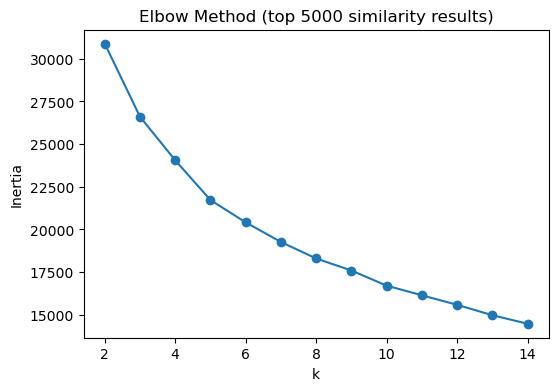

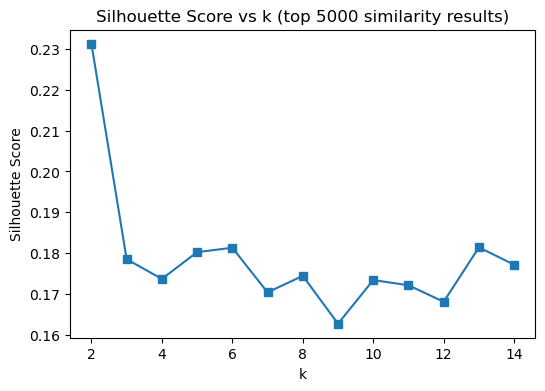

In [76]:
# Plot K-Means results
# Plot Elbow (Inertia)
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (top 5000 similarity results)")
plt.show()

# Plot Silhouette
plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_scores, marker='s')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k (top 5000 similarity results)")
plt.show()

* Initial interpretation: 
 - The Elbow plot tracks the number of clusters (k) vs inertia (within-cluster variance), where inertia = sum of squared distances of points to their cluster centers. Inertia always drops as k increases because more clusters implies smaller goups implies tighter fits. We're looking for sharp drops where adding more stops giving big improvements (the 'elbow'). Our curve is smooth suggesitng no clear cluster structure.
 - Silhouette score is max of ~0.23 at k = 2, which suggests 2 natural clusters, but with a Silhouette score in that range it suggests weak / moderate clustering. However, given we had originally 6 features (hbd, hba, tpsa, logP, mw, rings), we're also going to look at k = 4 clusters in addition to k = 2 to potentially reveal more meaningful chemical substructure diversity.



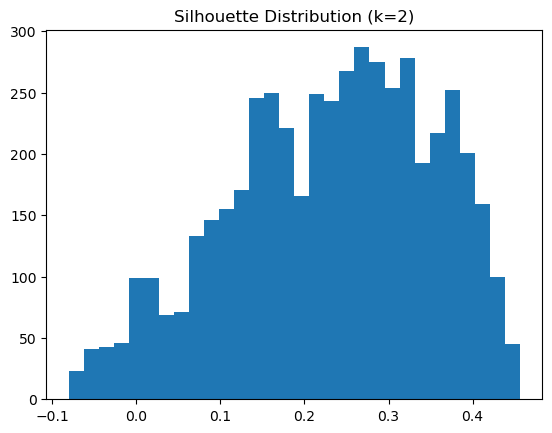

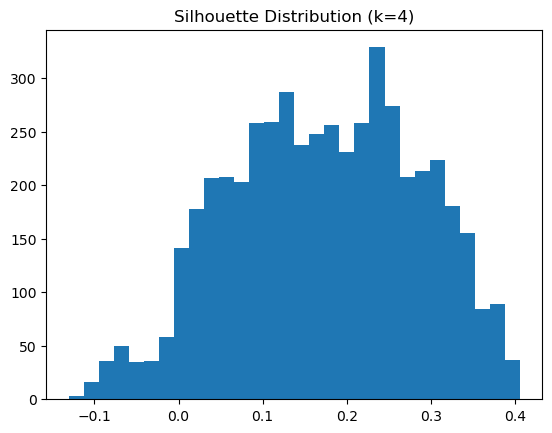

In [77]:
# Plotting silhouette per cluster for K=2, k=4:
labels_k2 = run_kmeans(X5000, 2)
labels_k4 = run_kmeans(X5000, 4)


# k=2
sample_sil_k2 = silhouette_samples(X5000, labels_k2)

plt.hist(sample_sil_k2, bins=30)
plt.title("Silhouette Distribution (k=2)")
plt.show()

# k=4
sample_sil_k4 = silhouette_samples(X5000, labels_k4)

plt.hist(sample_sil_k4, bins=30)
plt.title("Silhouette Distribution (k=4)")
plt.show()


* Quick analysis: 

The correlation matrix reveals chemically consistent relationships between features, particularly strong coupling between polarity (TPSA), hydrogen bonding (HBA/HBD), and molecular weight. The weak global correlation between ring count and aromatic ring count reflects heterogeneous subpopulations rather than an error, as aromatic rings represent only a subset of total rings. Overall, the feature set is non-redundant and captures multiple independent chemical dimensions, supporting its suitability for clustering and dimensionality reduction.

Low correlation between HBA/HBD and logP/TPSA can be normal depending on the dataset. However, a near-zero correlation between total rings and aromatic rings is unexpected, since aromatic rings are a subset of total rings. This suggests either a data distribution issue (e.g., many molecules with zero rings) or a potential problem in feature extraction. Additional diagnostics such as value distributions and scatter plots should be used to confirm whether this reflects true data characteristics or a bug.

* Reasoning about k number of clusters:
k = 2 should be used as the primary clustering result because it is supported by silhouette analysis and reflects the strongest structure in the data. k = 4 can be used as a secondary, exploratory clustering to reveal finer chemical substructure, provided that the resulting clusters are interpretable add meaningful insight beyond the k = 2 partition.

In [78]:
#Debug
print("k=2 clusters:", len(set(labels_k2)))
print("k=4 clusters:", len(set(labels_k4)))

{
    "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
    "rings": rdMolDescriptors.CalcNumRings(mol),
}

feat_5000.groupby("rings")["aromatic_rings"].mean()

k=2 clusters: 2
k=4 clusters: 4


rings
2    0.595194
3    0.888378
4    0.842308
5    0.766957
Name: aromatic_rings, dtype: float64

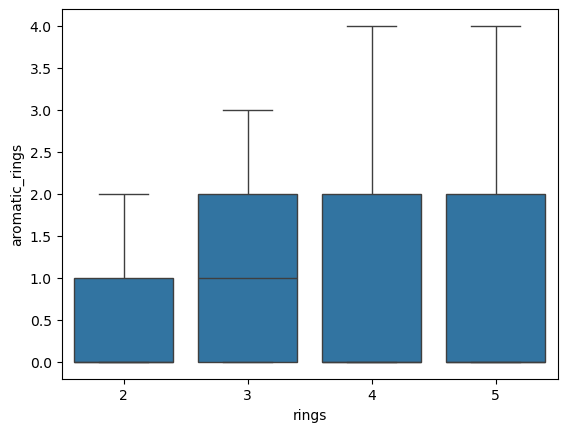

In [79]:
import seaborn as sns

sns.boxplot(x="rings", y="aromatic_rings", data=feat_5000)
plt.show()

* Quick analysis about the low correlation between 'rings' and 'aromatic rings': 
Although the overall correlation between total rings and aromatic rings appears low, grouping by total ring count reveals a clear positive relationship. This indicates that the low global correlation is due to heterogeneous subpopulations rather than a lack of underlying structure. The features are therefore valid and informative for downstream analysis.

In [80]:
# P4.A Scaling features defined
feature_cols = [
    "hbd", "hba", "rings", "aromatic_rings",
    "tpsa", "logp", "mw", "amide"
]

scaler = StandardScaler()
X = scaler.fit_transform(feat_5000[feature_cols])   # Scaled feature dataset


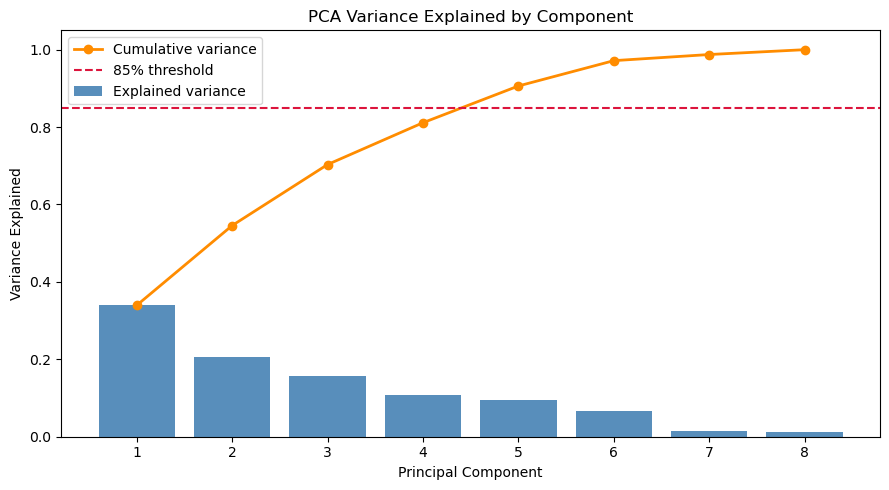

In [81]:
# P4.B PCA variance and projection
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Variance plot (bars for explained variance per component)
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(9, 5))
plt.bar(components, explained_var, color="steelblue", alpha=0.9, label="Explained variance")

# Cumulative variance as a line on top
plt.plot(components, cumulative_var, color="darkorange", marker="o", linewidth=2, label="Cumulative variance")

plt.axhline(0.85, linestyle="--", color="crimson", label="85% threshold")
plt.xticks(components)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Variance Explained by Component")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# P4.C UMAP 

